<a href="https://colab.research.google.com/github/evelyn450511/ModelosEstocasticos-EDTS-/blob/main/Simul_var_alea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIMULACIÓN DE VARIABLES ALEATORIAS (MÉTODO DE LA TRANSFORMADA INVERSA)
*Evelyn Daniela Tapia Serrano*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma

plt.style.use('seaborn-v0_8-whitegrid')
N = 10000


**(1) Distribución Weibull $We(α,1)$**

La función de distribución acumulada (CDF) es $F(x)=1-e^{-x^{-α}}$

Aplicando el método de la transformada inversa:
$x=F^{-1}(u)=[-ln(1-u)]^{1/α}$

--- WEIBULL (alpha=2.0) ---
Media: 0.8891 | Varianza: 0.2179 | Desv. Std: 0.4668


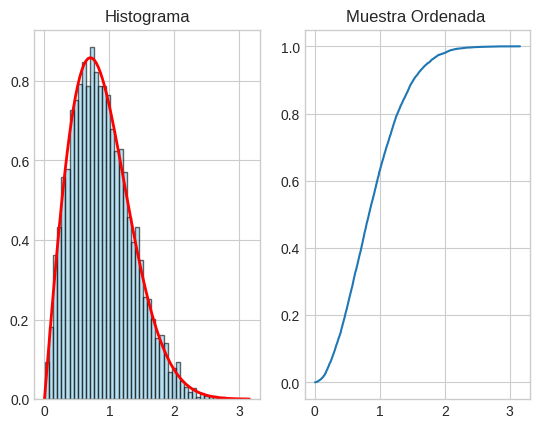

In [11]:
alpha = 2.0
U = np.random.rand(N)
X = (-np.log(U))**(1 / alpha)

print(f"--- WEIBULL (alpha={alpha}) ---")
print(f"Media: {np.mean(X):.4f} | Varianza: {np.var(X):.4f} | Desv. Std: {np.std(X):.4f}")

# Histograma
plt.subplot(1, 2, 1)
plt.hist(X, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
_x = np.linspace(0, np.max(X), 100)
plt.plot(_x, alpha * _x**(alpha-1) * np.exp(-_x**alpha), 'r', lw=2)
plt.title('Histograma')

plt.subplot(1, 2, 2)
plt.plot(np.sort(X), np.arange(1, N+1)/N)
plt.title('Muestra Ordenada ')
plt.show()

**(2)Distribución Gumbel $Gu(0,1)$**


La función de distribución acumulada (CDF) es $F(x)=e^{-e^{-x}}$

Aplicando el método de la transformada inversa:
$x=-ln(-ln(U))$

--- GUMBEL (0, 1) ---
Media: 0.5851 | Varianza: 1.6092 | Desv. Std: 1.2685


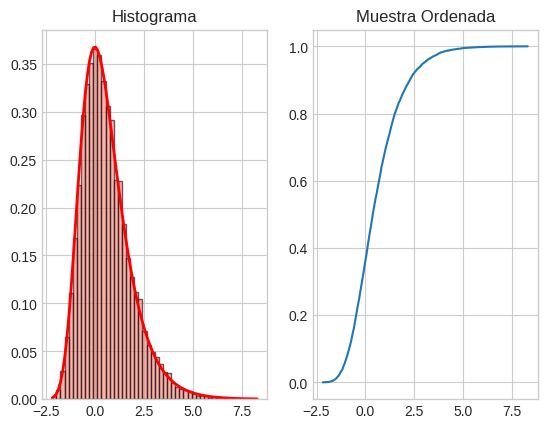

In [10]:
U = np.random.rand(N)
X = -np.log(-np.log(U))

print(f"--- GUMBEL (0, 1) ---")
print(f"Media: {np.mean(X):.4f} | Varianza: {np.var(X):.4f} | Desv. Std: {np.std(X):.4f}")

plt.subplot(1, 2, 1)
plt.hist(X, bins=50, density=True, alpha=0.6, color='salmon', edgecolor='black')
_x = np.linspace(np.min(X), np.max(X), 100)
plt.plot(_x, np.exp(-(_x + np.exp(-_x))), 'r', lw=2)
plt.title('Histograma')

plt.subplot(1, 2, 2)
plt.plot(np.sort(X), np.arange(1, N+1)/N)
plt.title('Muestra Ordenada')
plt.show()


**(3)Distribución Cauchy $C(0,1)$**

La función de distribución acumulada (CDF) es $F(x)=\frac{1}{π}arctan(x)+\frac{1}{2}$

Aplicando el método de la transformada inversa:
$x=tan(π(U-0.5))$

--- CAUCHY (0, 1) ---
Media de la muestra: -2.8066 (Teórica: No definida)


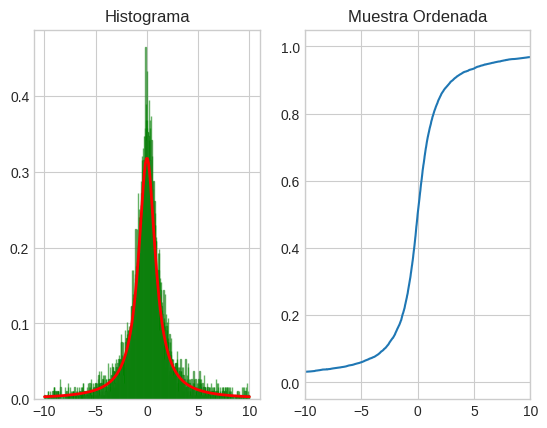

In [9]:
U = np.random.rand(N)
X = np.tan(np.pi * (U - 0.5))

print(f"--- CAUCHY (0, 1) ---")
print(f"Media de la muestra: {np.mean(X):.4f} (Teórica: No definida)")

plt.subplot(1, 2, 1)
plt.hist(X, bins=1000, density=True, alpha=0.6, range=(-10, 10), color='plum', edgecolor='green')
_x = np.linspace(-10, 10, 200)
plt.plot(_x, 1 / (np.pi * (1 + _x**2)), 'r', lw=2)
plt.title('Histograma')

plt.subplot(1, 2, 2)
plt.plot(np.sort(X), np.arange(1, N+1)/N)
plt.xlim(-10, 10)
plt.title('Muestra Ordenada')
plt.show()


**(4)Distribución Laplace $𝓛(0,1)$**


La función de distribución acumulada (CDF) es

$F(x)=\frac{1}{2}e^{x}$ $si$ $x< 0$

$F(x)=1- \frac{1}{2}e^{x}$ $si$ $x \leq 0$

Aplicando el método de la transformada inversa:
$x=tan(π(U-0.5))$

--- LAPLACE (0, 1) ---
Media: 0.0044 | Varianza: 2.0201 | Desv. Std: 1.4213


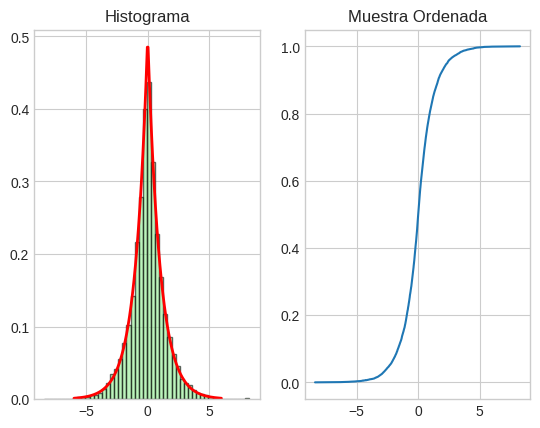

In [8]:
U = np.random.rand(N)
X = np.where(U < 0.5, np.log(2*U), -np.log(2*(1-U)))

print(f"--- LAPLACE (0, 1) ---")
print(f"Media: {np.mean(X):.4f} | Varianza: {np.var(X):.4f} | Desv. Std: {np.std(X):.4f}")

plt.subplot(1, 2, 1)
plt.hist(X, bins=50, density=True, alpha=0.6, color='lightgreen', edgecolor='black')
_x = np.linspace(-6, 6, 200)
plt.plot(_x, 0.5 * np.exp(-np.abs(_x)), 'r', lw=2)
plt.title('Histograma')

plt.subplot(1, 2, 2)
plt.plot(np.sort(X), np.arange(1, N+1)/N)
plt.title('Muestra Ordenada')
plt.show()

**(5)Distribución de Pareto $Par(α)$**

La función de distribución acumulada (CDF) es $F(x)=1-x^{-α}$$para$ $ x\geq1$

Aplicando el método de la transformada inversa:
$x=U^{-\frac{1}{α}}$

--- PARETO (alpha=3.0) ---
Media: 1.4945 | Varianza: 0.7131 | Desv. Std: 0.8444


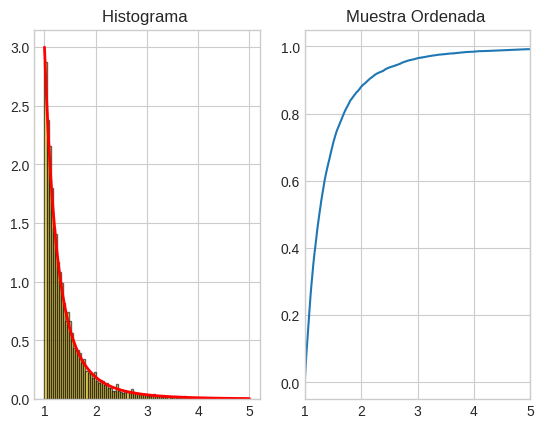

In [12]:
alpha_p = 3.0
U = np.random.rand(N)
X = U**(-1 / alpha_p)

print(f"--- PARETO (alpha={alpha_p}) ---")
print(f"Media: {np.mean(X):.4f} | Varianza: {np.var(X):.4f} | Desv. Std: {np.std(X):.4f}")

plt.subplot(1, 2, 1)
plt.hist(X, bins=100, density=True, alpha=0.6, range=(1, 5), color='gold', edgecolor='black')
_x = np.linspace(1, 5, 100)
plt.plot(_x, alpha_p * _x**(-alpha_p - 1), 'r', lw=2)
plt.title('Histograma ')

plt.subplot(1, 2, 2)
plt.plot(np.sort(X), np.arange(1, N+1)/N)
plt.xlim(1, 5)
plt.title('Muestra Ordenada ')
plt.show()